In [1]:
# import library 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import data 
train_df = pd.read_csv(r"C:\Users\Raifu Sodiq\Downloads\DNS_BOOTCAMP\train.csv")
train_df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [13]:
# Check data info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    6818 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           6818 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [14]:
# Check data describtion 
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_weight_kg,6818.0,12.850876,4.208398,4.482,9.4380,12.850876,15.95375,21.8830
shelf_visibility,6818.0,0.065527,0.051566,0.000,0.0266,0.053200,0.09340,0.3201
product_price,6818.0,140.473623,62.413513,31.110,93.2800,142.065000,185.98750,273.0400
store_age_years,6818.0,34.178205,8.384574,23.000,28.0000,33.000000,45.00000,47.0000
total_sales,6818.0,2174.756574,1697.894956,32.700,834.7925,1790.890000,3092.58750,12996.8200


# Data Cleaning 

In [15]:
# Check Duplicate 
train_df.duplicated().sum()

np.int64(0)

In [16]:
# Check missing number 
train_df.isna().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

# Check inconsistency 

In [17]:
# List of categorical column aside product code 
cat_col = ["fat_content", "product_category", "store_code", "store_size", "store_location_tier", "store_format"]

In [18]:
# iterate for each column 

for cat in cat_col:
    print(cat,train_df[cat].nunique())
    print(train_df[cat].unique())
    print("-" * 50)

fat_content 2
['Low Fat' 'Regular']
--------------------------------------------------
product_category 16
['Frozen Foods' 'Health And Hygiene' 'Canned' 'Soft Drinks' 'Meat'
 'Snack Foods' 'Baking Goods' 'Household' 'Dairy' 'Fruits And Vegetables'
 'Breakfast' 'Breads' 'Seafood' 'Others' 'Hard Drinks' 'Starchy Foods']
--------------------------------------------------
store_code 10
['STORE-AGY' 'STORE-YLW' 'STORE-89Z' 'STORE-7WS' 'STORE-9RG' 'STORE-HL7'
 'STORE-JOR' 'STORE-T5G' 'STORE-OYG' 'STORE-DKU']
--------------------------------------------------
store_size 3
['Large' 'Small' 'Medium']
--------------------------------------------------
store_location_tier 3
['Tier_3' 'Tier_1' 'Tier_2']
--------------------------------------------------
store_format 4
['Standard Supermarket' 'Flagship Hypermarket' 'Superstore' 'Corner Shop']
--------------------------------------------------


In [19]:
# Remove inconsistency in product_catgory 
train_df['product_category'] = (train_df['product_category'].str.strip().str.title())

In [20]:
# Re-iterate cat_col
for cat in cat_col:
    print(train_df[cat].nunique())
    print(train_df[cat].unique())
    print("-" * 50)

2
['Low Fat' 'Regular']
--------------------------------------------------
16
['Frozen Foods' 'Health And Hygiene' 'Canned' 'Soft Drinks' 'Meat'
 'Snack Foods' 'Baking Goods' 'Household' 'Dairy' 'Fruits And Vegetables'
 'Breakfast' 'Breads' 'Seafood' 'Others' 'Hard Drinks' 'Starchy Foods']
--------------------------------------------------
10
['STORE-AGY' 'STORE-YLW' 'STORE-89Z' 'STORE-7WS' 'STORE-9RG' 'STORE-HL7'
 'STORE-JOR' 'STORE-T5G' 'STORE-OYG' 'STORE-DKU']
--------------------------------------------------
3
['Large' 'Small' 'Medium']
--------------------------------------------------
3
['Tier_3' 'Tier_1' 'Tier_2']
--------------------------------------------------
4
['Standard Supermarket' 'Flagship Hypermarket' 'Superstore' 'Corner Shop']
--------------------------------------------------


# Working on missing data  

In [21]:
# fill the missing number with the mean
weight_mean = train_df["product_weight_kg"].mean()

train_df["product_weight_kg"] = train_df["product_weight_kg"].fillna(weight_mean)

In [22]:
# Check the most common store_zize to fill the missing store size
train_df["store_size"].mode()

0    Medium
Name: store_size, dtype: object

In [23]:
# Fill missing number with thetrain_df["store_size"] mode 
train_df["store_size"] = train_df["store_size"].fillna("Medium")

In [24]:
train_df.isna().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [25]:
# Drop the id column and save clean data as train 
train = train_df.drop("id", axis = 1)

# Exploratory Data Analysis

In [365]:
train.head()

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698000,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.850876,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338000,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [366]:
# Mean sales for each fat content 
fat_sales = train.groupby("fat_content")["total_sales"].mean().reset_index()
fat_sales

,fat_content,total_sales
0,Low Fat,2151.165785
1,Regular,2218.379323


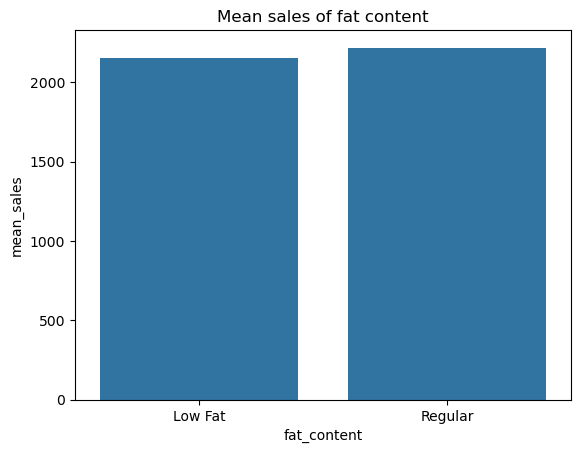

In [367]:
# Visualizing mean sales for fat content 
sns.barplot(data = fat_sales, x = "fat_content", y= "total_sales")
plt.ylabel('mean_sales')
plt.title('Mean sales of fat content')
plt.show()

In [368]:
# product_category 
train["product_category"].value_counts()

product_category
Fruits And Vegetables    1006
Snack Foods               933
Household                 740
Frozen Foods              675
Dairy                     554
Canned                    517
Baking Goods              516
Health And Hygiene        412
Soft Drinks               366
Meat                      339
Breads                    209
Hard Drinks               169
Others                    132
Starchy Foods             113
Breakfast                  85
Seafood                    52
Name: count, dtype: int64

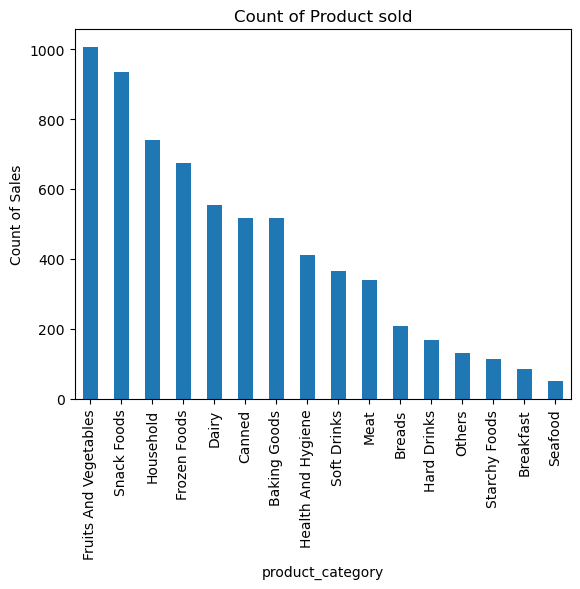

In [369]:
# visualing sales of product category 
train["product_category"].value_counts().plot(kind = "bar")
plt.title("Count of Product sold")
plt.ylabel("Count of Sales")
plt.show()

In [370]:
# Total sales by product category 
train.groupby("product_category")["total_sales"].sum().sort_values(ascending = False)

product_category
Fruits And Vegetables    2291521.80
Snack Foods              2074833.92
Household                1696423.85
Frozen Foods             1445019.84
Dairy                    1240027.66
Canned                   1135538.15
Baking Goods             1002803.10
Health And Hygiene        822461.61
Meat                      767601.22
Soft Drinks               720068.20
Breads                    456905.95
Hard Drinks               370063.22
Starchy Foods             272072.20
Others                    257061.53
Breakfast                 157436.81
Seafood                   117651.26
Name: total_sales, dtype: float64

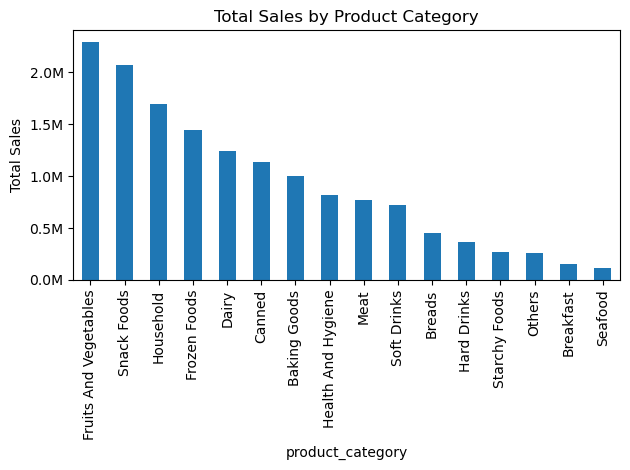

In [371]:
# Total Amount of sales for product category (Visualization)
import matplotlib.ticker as ticker 
train.groupby("product_category")["total_sales"].sum().sort_values(ascending = False).plot(kind = 'bar')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product Category')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.tight_layout()

In [372]:
# Working with Store_Code 
train["store_code"].unique()

array(['STORE-AGY', 'STORE-YLW', 'STORE-89Z', 'STORE-7WS', 'STORE-9RG',
       'STORE-HL7', 'STORE-JOR', 'STORE-T5G', 'STORE-OYG', 'STORE-DKU'],
      dtype=object)

In [373]:
# Count of sales in each store 
train["store_code"].value_counts()

store_code
STORE-YLW    754
STORE-9RG    752
STORE-AGY    748
STORE-7WS    748
STORE-OYG    744
STORE-HL7    742
STORE-DKU    736
STORE-89Z    728
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64

In [374]:
# Number of product sales in each store 
product_in_store = train.groupby("store_code")["product_category"].value_counts().reset_index()
product_in_store

,store_code,product_category,count
0,STORE-7WS,Fruits And Vegetables,116
1,STORE-7WS,Snack Foods,103
2,STORE-7WS,Household,82
3,STORE-7WS,Frozen Foods,71
4,STORE-7WS,Baking Goods,58
...,...,...,...
155,STORE-YLW,Others,18
156,STORE-YLW,Hard Drinks,16
157,STORE-YLW,Starchy Foods,11
158,STORE-YLW,Breakfast,9


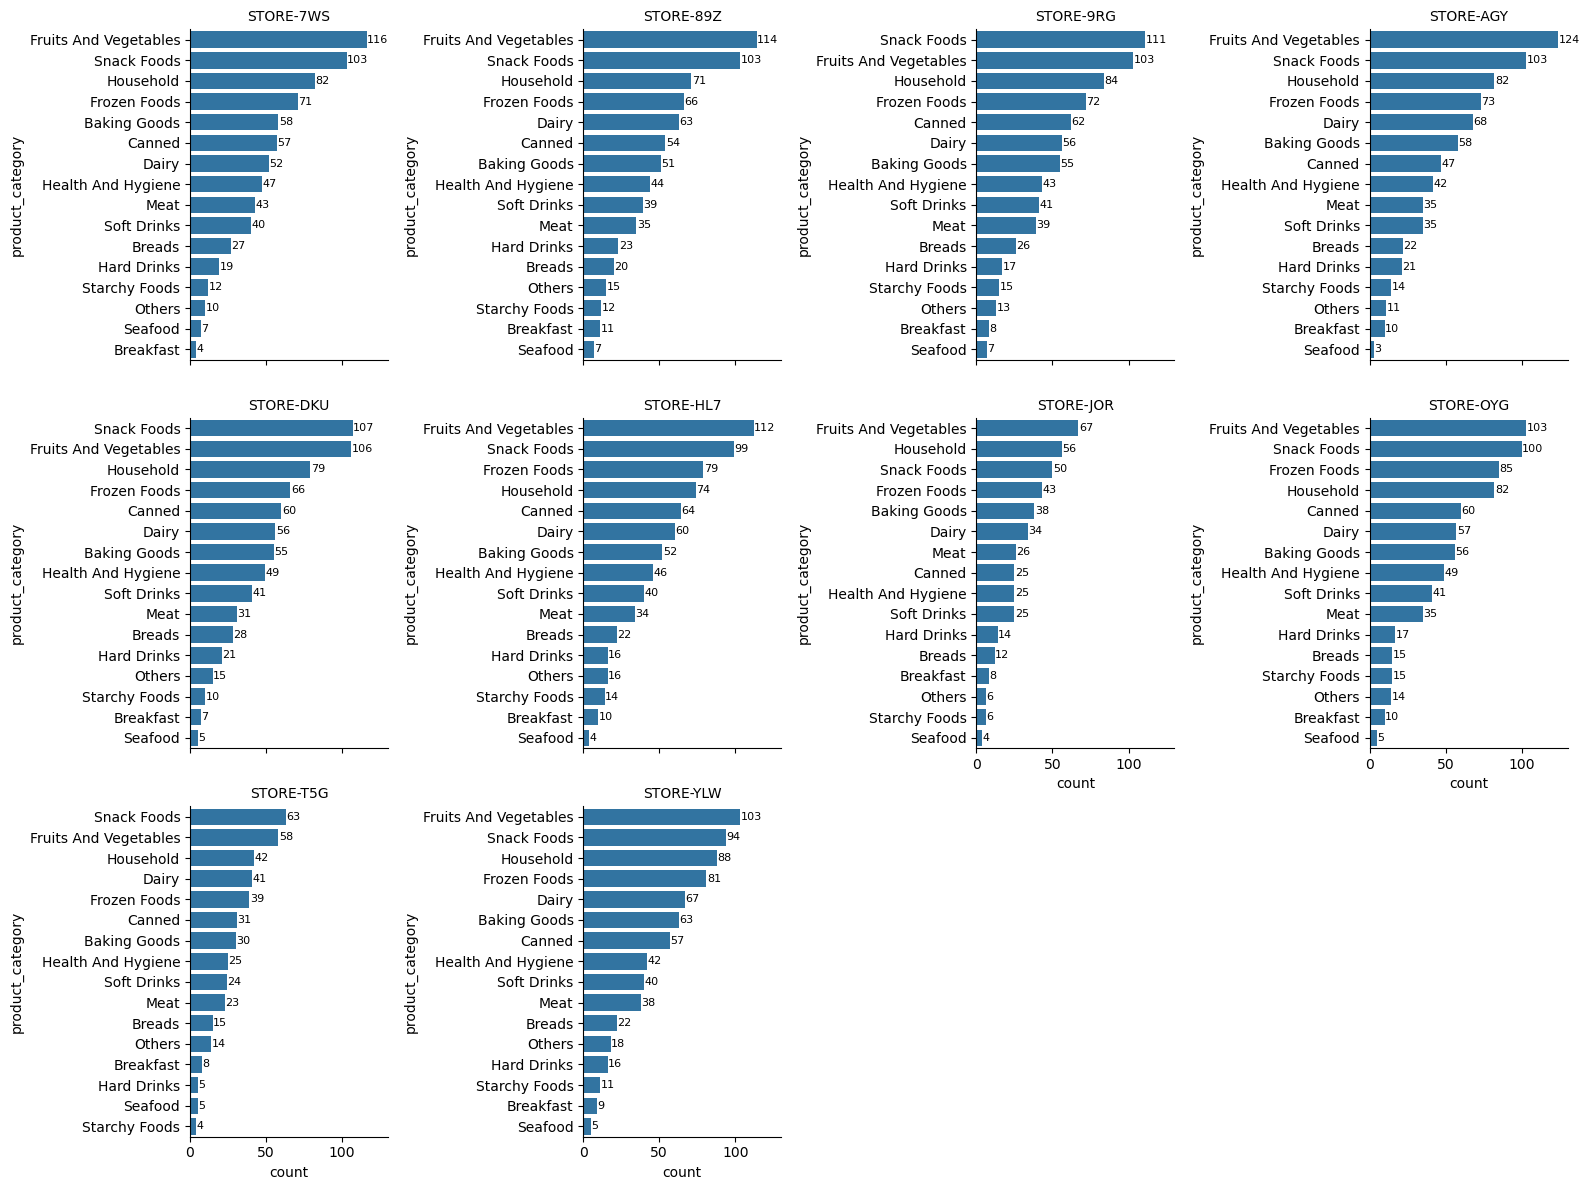

In [375]:
#  Visualiazing Number of product sales in each store 
# FacetGrid
g = sns.FacetGrid(product_in_store, col = "store_code", col_wrap = 4, height = 4, sharey = False)
# Custom function to add labels 
def bar_with_labels(data, **kws):
    ax = plt.gca()
    sns.barplot(data = data, x = 'count', y = 'product_category', ax = ax)

    # Add count in front of each bar 
    for i, count in enumerate(data['count']):
        ax.text(count + 0.3, i, str(count), va = 'center', fontsize =8)

g.map_dataframe(bar_with_labels)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [376]:
# Working on Store Format
train['store_format'].unique()

array(['Standard Supermarket', 'Flagship Hypermarket', 'Superstore',
       'Corner Shop'], dtype=object)

In [377]:
# Total Sales by Store format
train.groupby('store_format')['total_sales'].sum().sort_values(ascending = False)

store_format
Standard Supermarket    10335418.40
Flagship Hypermarket     2737816.30
Superstore               1462973.17
Corner Shop               291282.45
Name: total_sales, dtype: float64

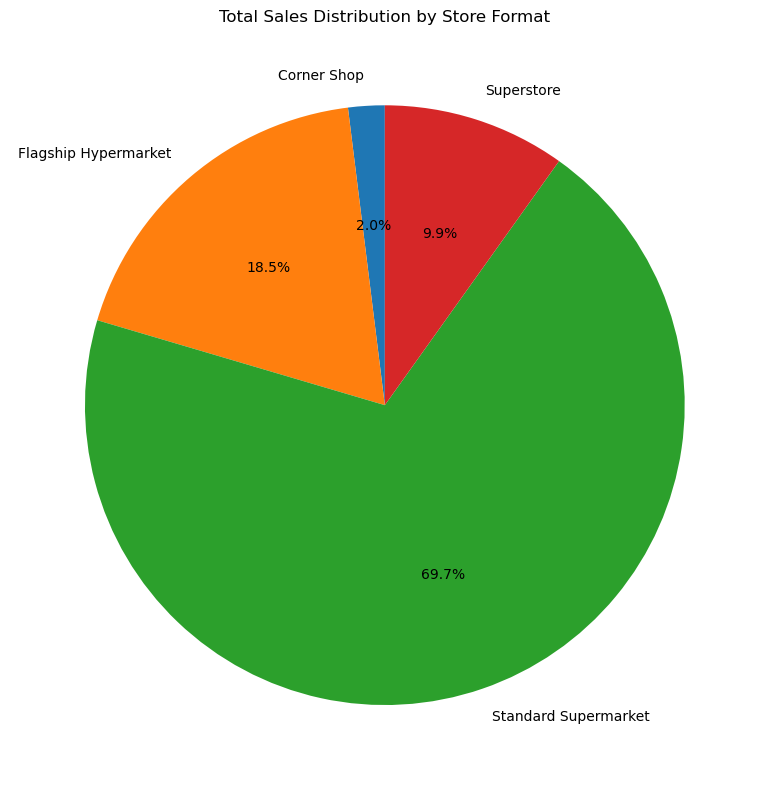

In [378]:
# Visualiazing Total Sales by store format 
sales_by_format = train.groupby("store_format")["total_sales"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    sales_by_format.values,
    labels=sales_by_format.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Total Sales Distribution by Store Format")
plt.tight_layout()
plt.show()

<Axes: xlabel='store_age_years', ylabel='total_sales'>

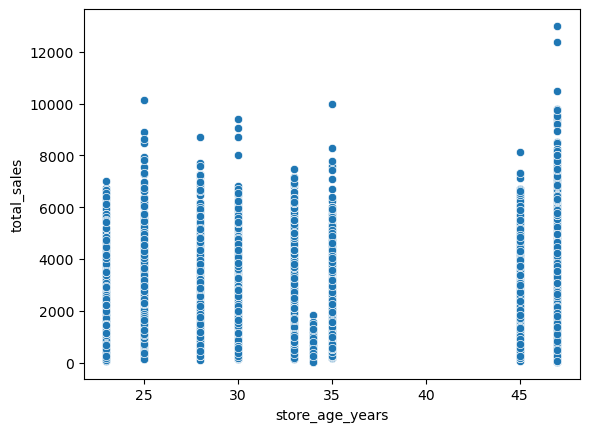

In [379]:
# Relationship between store age and total sales 
sns.scatterplot(data = train, x= 'store_age_years', y = 'total_sales')

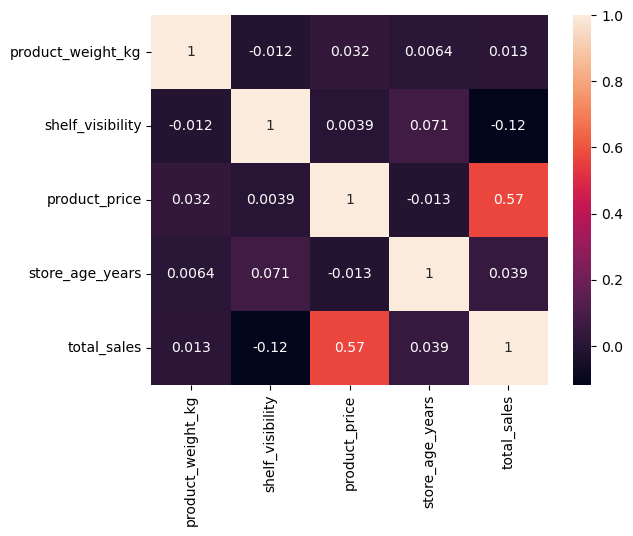

In [380]:
# Check correclation 
sns.heatmap(train.corr(numeric_only = True), annot = True)
plt.show()  

In [381]:
# Corelation for all numeric variable 
corr = train.corr(numeric_only = True)
corr

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
product_weight_kg,1.000000,-0.011999,0.031653,0.006424,0.012749
shelf_visibility,-0.011999,1.000000,0.003905,0.071078,-0.118124
product_price,0.031653,0.003905,1.000000,-0.012747,0.569833
store_age_years,0.006424,0.071078,-0.012747,1.000000,0.039443
total_sales,0.012749,-0.118124,0.569833,0.039443,1.000000


# Features Engineering 

In [26]:
# Build product-level mean visibility from train only
product_mean_vis = train.groupby('product_code')['shelf_visibility'].mean()

train['visibility_mean_ratio'] = train['shelf_visibility'] / train['product_code'].map(product_mean_vis)
train['visibility_mean_ratio'] = train['visibility_mean_ratio'].fillna(1.0)

In [27]:
train['price_per_kg'] = train['product_price'] / train['product_weight_kg']

In [28]:
cat_mean_price = train.groupby('product_category')['product_price'].mean()

train['price_vs_category_mean'] = train['product_price'] / train['product_category'].map(cat_mean_price)

# Correlation 

In [29]:
train.corr(numeric_only = True)

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales,visibility_mean_ratio,price_per_kg,price_vs_category_mean
product_weight_kg,1.000000,-0.011999,0.031653,0.006424,0.012749,-0.008779,-0.579966,0.024976
shelf_visibility,-0.011999,1.000000,0.003905,0.071078,-0.118124,0.389048,-0.000663,0.002263
product_price,0.031653,0.003905,1.000000,-0.012747,0.569833,-0.001022,0.707424,0.991680
store_age_years,0.006424,0.071078,-0.012747,1.000000,0.039443,0.145898,-0.073540,-0.013978
total_sales,0.012749,-0.118124,0.569833,0.039443,1.000000,-0.191451,0.394324,0.565669
visibility_mean_ratio,-0.008779,0.389048,-0.001022,0.145898,-0.191451,1.000000,-0.011472,-0.001027
price_per_kg,-0.579966,-0.000663,0.707424,-0.073540,0.394324,-0.011472,1.000000,0.705948
price_vs_category_mean,0.024976,0.002263,0.991680,-0.013978,0.565669,-0.001027,0.705948,1.000000


# multicolinerity 

In [396]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical columns
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns

# Remove the target variable
numeric_cols = numeric_cols.drop("total_sales")

# Create numerical dataset
X_numeric = train[numeric_cols].copy()

# Handle missing values

# Calculate VIF
vif = pd.DataFrame()

vif["Feature"] = X_numeric.columns

vif["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

# Sort from highest to lowest
vif = vif.sort_values("VIF", ascending=False)

print(vif)

                  Feature         VIF
2           product_price  376.889642
6  price_vs_category_mean  369.409996
0       product_weight_kg   15.499782
5            price_per_kg   14.635323
3         store_age_years   13.000853
4   visibility_mean_ratio   10.214270
1        shelf_visibility    3.081673


In [30]:
train.drop(columns=['price_vs_category_mean','price_per_kg','visibility_mean_ratio'], inplace=True)

In [31]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical columns
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns

# Remove the target variable
numeric_cols = numeric_cols.drop("total_sales")

# Create numerical dataset
X_numeric = train[numeric_cols].copy()

# Handle missing values

# Calculate VIF
vif = pd.DataFrame()

vif["Feature"] = X_numeric.columns

vif["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

# Sort from highest to lowest
vif = vif.sort_values("VIF", ascending=False)

print(vif)

             Feature       VIF
3    store_age_years  9.027579
0  product_weight_kg  7.550589
2      product_price  5.171916
1   shelf_visibility  2.546728


# Model 

In [32]:
#import library
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error

In [33]:
# select the depandent variable as y and independent x
y = train["total_sales"].values
X = train.drop("total_sales", axis = 1)

# Encoding 

In [34]:
# Encode the categorical column using OneHotEncoder and convert to dataframe

# select the categorical columns in X
cat_col = X.select_dtypes(include="object").columns

# Instantiate encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns
encoded_data = encoder.fit_transform(X[cat_col])

# Convert to DataFrame 
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_col), index=X.index )

# Drop categorical columns
da_ta = X.drop(columns=cat_col)

# Concatenate
da_ta = pd.concat([da_ta, encoded_df], axis=1)

# Split the dataframe into train and test

In [35]:
X_train, X_test, y_train, y_test = train_test_split(da_ta,y, test_size=0.2,random_state= 10)

# Model 

In [36]:
reg = LinearRegression()

In [37]:
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred = reg.predict(X_test)

In [39]:
r = r2_score(y_test, y_pred)
r

0.41870039636015977

In [40]:
RMSE_score = root_mean_squared_error(y_test, y_pred)
RMSE_score

1301.8022246241367

# XGBOOST MODEL

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    subsample=1.0,
    reg_lambda=2.0,
    reg_alpha=1.0,
    n_estimators=500,
    min_child_weight=10,
    max_depth=3,
    learning_rate=0.02,
    gamma=0.5,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [42]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
y_pred = xgb.predict(X_test)

In [45]:
R2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("R2:", R2, "\nRMSE:", rmse)

R2: 0.6251658255604557 
RMSE: 1045.356889273786


# Prediction with test data 

In [52]:
test_df = pd.read_csv(r'C:\Users\Raifu Sodiq\Downloads\DNS_BOOTCAMP\test.csv')

In [53]:
test_df.isna().sum()

id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

In [54]:
# Remove inconsistency in product_catgory 
test_df['product_category'] = (test_df['product_category'].str.strip().str.title())

In [55]:
test_df["store_size"] = test_df["store_size"].fillna("Medium")
test_df["product_weight_kg"] = test_df["product_weight_kg"].fillna(weight_mean)

In [56]:
# Set the column id 
id = test_df["id"]

In [57]:
test_df = test_df.drop(["id"], axis =1)

In [58]:
# Encode the categorical column 
test_encoded_cat = encoder.transform(test_df[cat_col])

test_encoded_cat = pd.DataFrame(test_encoded_cat,columns=encoder.get_feature_names_out(cat_col),index=test_df.index)

test_da = test_df.drop(columns=cat_col).copy()

test_da = pd.concat([test_da, test_encoded_cat],axis=1)

In [60]:
sales = xgb.predict(test_da)

In [63]:
sub = pd.DataFrame({"id" : id,
                    "total_sales" : sales})
sub

,id,total_sales
0,row_00009,2691.547852
1,row_00015,4234.403320
2,row_00019,3181.692871
3,row_00020,3027.250732
4,row_00023,2511.821533
...,...,...
1700,row_08483,2784.528564
1701,row_08489,316.990051
1702,row_08491,2739.820312
1703,row_08504,4260.128418


In [62]:
sub.to_csv("submit14.csv", index = False)